In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from scipy.stats import zscore

In [2]:
valuation = pd.read_csv("../reports/valuation_flags.csv")

clusters = pd.read_csv("../output/cluster_labels.csv")

df = valuation.merge(
    clusters,
    on="company_id"
)

df.head()

,company_id,roe,opm_percentage,net_profit,eps,profit_before_tax,valuation_score,valuation_rating,cluster_id,cluster_name
0,ABB,0.0,12.0,145,68.0,215,47.1,Weak,1,Stable
1,ABB,0.0,12.0,145,68.0,215,47.1,Weak,1,Stable
2,ABB,0.0,12.0,145,68.0,215,47.1,Weak,1,Stable
3,ABB,0.0,12.0,145,68.0,215,47.1,Weak,1,Stable
4,ABB,0.0,12.0,145,68.0,215,47.1,Weak,1,Stable


In [3]:
numeric_cols = [
    "roe",
    "opm_percentage",
    "net_profit",
    "valuation_score"
]

df[numeric_cols].head()

,roe,opm_percentage,net_profit,valuation_score
0,0.0,12.0,145,47.1
1,0.0,12.0,145,47.1
2,0.0,12.0,145,47.1
3,0.0,12.0,145,47.1
4,0.0,12.0,145,47.1


In [4]:
cluster_profile = (
    df.groupby("cluster_name")[numeric_cols]
      .agg(["mean", "median"])
      .round(2)
)

cluster_profile

roe        opm_percentage         net_profit           \
               mean median           mean  median       mean   median   
cluster_name                                                            
Emerging       7.00    5.0       -3045.95  7214.0   27234.37  20364.0   
High Growth    9.27    5.0        3860.59  3534.0   28344.02  24338.0   
Moderate      15.00    7.5          26.81    27.0   24248.46  23127.0   
Stable         1.46    0.0         115.92    18.0    3104.97   1639.0   
Value          8.91    5.0         617.41    26.0   17941.49  13489.0   

             valuation_score          
                        mean  median  
cluster_name                          
Emerging             7259.32  6558.6  
High Growth          9665.09  8954.4  
Moderate             7288.58  6952.6  
Stable                966.85   520.3  
Value                5571.24  4313.0

In [5]:
cluster_profile.to_csv(
    "../output/cluster_profile.csv"
)

print("Cluster profile generated.")

Cluster profile generated.


In [6]:
corr = df[numeric_cols].corr()

corr

,roe,opm_percentage,net_profit,valuation_score
roe,1.000000,0.005756,0.354471,0.339277
opm_percentage,0.005756,1.000000,-0.205557,0.378699
net_profit,0.354471,-0.205557,1.000000,0.827911
valuation_score,0.339277,0.378699,0.827911,1.000000


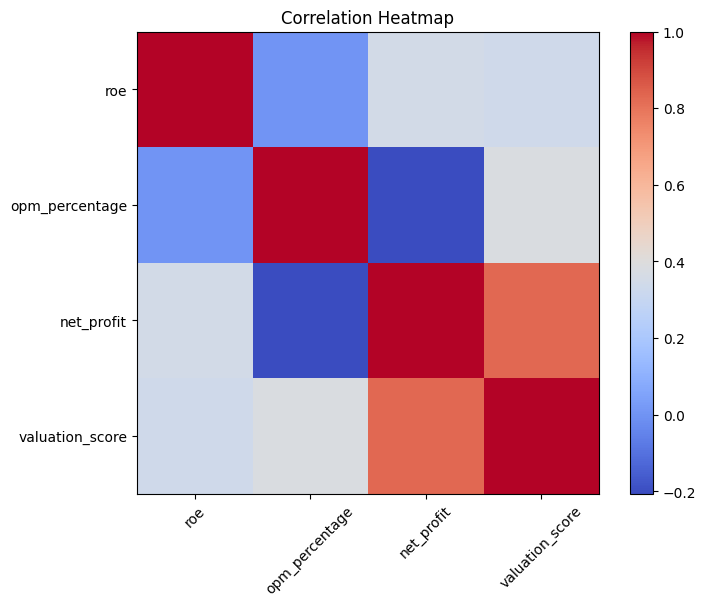

In [15]:
plt.figure(figsize=(8,6))

plt.imshow(corr, cmap="coolwarm")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar()

plt.title("Correlation Heatmap")

os.makedirs("../reports", exist_ok=True)

plt.savefig("../reports/correlation_heatmap.png")

plt.show()

In [16]:
z = np.abs(
    zscore(df[numeric_cols])
)

outliers = df[
    (z > 3).any(axis=1)
]

outliers

,company_id,roe,opm_percentage,net_profit,eps,profit_before_tax,valuation_score,valuation_rating,cluster_id,cluster_name
4596,COALINDIA,0.0,44232.0,31723,52.0,43275,22786.5,Strong,0,High Growth
4597,COALINDIA,0.0,44232.0,31723,52.0,43275,22786.5,Strong,0,High Growth
4598,COALINDIA,0.0,44232.0,31723,52.0,43275,22786.5,Strong,0,High Growth
4599,COALINDIA,0.0,44232.0,31723,52.0,43275,22786.5,Strong,0,High Growth
4600,COALINDIA,0.0,44232.0,31723,52.0,43275,22786.5,Strong,2,Value
...,...,...,...,...,...,...,...,...,...,...
24532,TCS,52.0,27.0,49006,135.0,65778,14730.7,Strong,3,Moderate
24533,TCS,52.0,27.0,49006,135.0,65778,14730.7,Strong,0,High Growth
24534,TCS,52.0,27.0,49006,135.0,65778,14730.7,Strong,0,High Growth
24535,TCS,52.0,27.0,49006,135.0,65778,14730.7,Strong,0,High Growth


In [17]:
outliers.to_csv(
    "../output/outlier_report.csv",
    index=False
)

print("Outlier report saved.")

Outlier report saved.


In [18]:
portfolio_stats = df[numeric_cols].describe(
    percentiles=[
        0.10,
        0.25,
        0.50,
        0.75,
        0.90
    ]
)

portfolio_stats

,roe,opm_percentage,net_profit,valuation_score
count,29333.000000,29333.000000,29333.000000,29333.000000
mean,5.000920,504.165786,10899.303447,3423.041138
std,9.531249,8434.391168,13915.266297,4415.701955
min,0.000000,-57587.000000,-30664.000000,-13584.600000
10%,0.000000,1.000000,630.000000,186.900000
25%,0.000000,13.000000,1422.000000,435.000000
50%,0.000000,23.000000,6020.000000,1864.600000
75%,5.000000,31.000000,14925.000000,4818.800000
90%,12.000000,4099.000000,27687.000000,9582.500000
max,52.000000,47971.000000,79941.000000,25602.000000


In [19]:
portfolio_stats = df[numeric_cols].describe(
    percentiles=[
        0.10,
        0.25,
        0.50,
        0.75,
        0.90
    ]
)

portfolio_stats

,roe,opm_percentage,net_profit,valuation_score
count,29333.000000,29333.000000,29333.000000,29333.000000
mean,5.000920,504.165786,10899.303447,3423.041138
std,9.531249,8434.391168,13915.266297,4415.701955
min,0.000000,-57587.000000,-30664.000000,-13584.600000
10%,0.000000,1.000000,630.000000,186.900000
25%,0.000000,13.000000,1422.000000,435.000000
50%,0.000000,23.000000,6020.000000,1864.600000
75%,5.000000,31.000000,14925.000000,4818.800000
90%,12.000000,4099.000000,27687.000000,9582.500000
max,52.000000,47971.000000,79941.000000,25602.000000


In [20]:
portfolio_stats.to_csv(
    "../output/portfolio_stats.csv"
)

print("Portfolio statistics generated.")

Portfolio statistics generated.
